# Inverse signal importance in real exposome: How do biological systems dynamically prioritize multiple environmental signals?

## Outline
This notebook reproduces the analysis in the following order:

#### 1. **Data Preprocessing**
   - Loading and interpolation of GSI time series
   - Standardization of input/output variables
   - Construction of sliding-window input matrix

#### 2. **Inverse Signal Importance (ISI): Single-Group Demonstration**
   - Application of the proposed method to Data Group 1 
   - Visualization of RSS and model fit
   - Visualization of response function and signal importance

#### 3. **Hyperparameter Selection via Grid Search**
   - Grid search over model hyperparameters
   - Evaluation criteria and selected values

#### 4. **Full Model: All Three Data Groups**
   - Application of the full pipeline to all groups (Data 1–3)
   - Aggregated results and figures as reported in the paper

In [20]:
!pip freeze > requirements.txt

In [117]:
import pandas as pd
%matplotlib inline
import numpy as np 
import seaborn as sns # グラフをきれいにする
import matplotlib.pyplot as plt # matlabの図のようにグラフを作ることができる
import matplotlib.dates as mdates
from scipy.stats import zscore # データを標準化するため（平均0, SD 1のデータに変換）
from scipy import interpolate # GSIのデータを補間するための関数
from scipy.signal import medfilt # median filter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
#Python version (development: 3.7.4)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from typing import Union, Sequence


#Make figure background white
sns.set_style("ticks")
sns.set_context("paper")
sns.set_palette("husl")
fontSize = 18

print(sys.version)

3.12.11 (main, Jun  3 2025, 15:41:47) [Clang 16.0.0 (clang-1600.0.26.6)]


## Data Processing

### Loading, interpolation, derivative of GSI time series

We divided the GSI data from 10 females into three groups: 
Data 1 (n = 3), Data 2 (n = 3), and Data 3 (n = 4), 
and computed the mean GSI for each group.
Each group-averaged time series was then independently interpolated 
at 1-day intervals to compute time derivative

In [118]:
def compute_time_derivative(target_df: pd.DataFrame, target_col: str) -> np.ndarray:
    time = target_df["Time"].to_numpy(dtype=float)
    values = target_df[target_col].to_numpy(dtype=float)
    n = len(time)
    delta = np.empty(n)
    delta[0] = np.polyfit(time[:2], values[:2], deg=1)[0]
    delta[-1] = np.polyfit(time[-2:], values[-2:], deg=1)[0]
    for i in range(1, n - 1):
        idx = slice(i - 1, i + 2)          # 3 点区間
        delta[i] = np.polyfit(time[idx], values[idx], deg=1)[0]

    return delta



def interpolate_time_series(target_df: pd.DataFrame, target_col: str, new_len: int) -> np.ndarray:
    """
    GSI 時系列データを、0～(len(df_input)-1) の均一刻みで補間する。
    """
    original_time = target_df['Time'].values
    target_val= target_df[target_col].values
    interpolator = interpolate.interp1d(
        original_time, target_val, kind='cubic', fill_value='extrapolate'
    )
    new_time = np.arange(new_len)
    tar_interp = interpolator(new_time)
    return tar_interp



Data1input = pd.read_csv("20151001_20171015_env_inGSI.csv", index_col=0)
Data1output = pd.read_csv("20151001_20171015_raw_GSIdata_ci.csv", index_col=0)

data_set1 =  ["Female"]+ [f"Female.{i}" for i in range(1,3)] #Full model
data_set2=   [f"Female.{i}" for i in range(3,6)] #Full model
data_set3=   [f"Female.{i}" for i in range(6,9)] #Full model
Data1output["Female_mean_for_data0"] = Data1output.loc[:,data_set1].mean(axis='columns')
Data1output["Female_mean_for_data1"] = Data1output.loc[:,data_set2].mean(axis='columns')
Data1output["Female_mean_for_data2"] = Data1output.loc[:,data_set3].mean(axis='columns')

Data1output["deltaFemaleGSI"] = compute_time_derivative(Data1output, "Female_mean")
Data1output["deltaFemaleGSI_for_data0"] = compute_time_derivative(Data1output, "Female_mean_for_data0")
Data1output["deltaFemaleGSI_for_data1"] = compute_time_derivative(Data1output, "Female_mean_for_data1")
Data1output["deltaFemaleGSI_for_data2"] = compute_time_derivative(Data1output, "Female_mean_for_data2")

Data1input["interporated GSI_Female_data0"] = interpolate_time_series(Data1output, 'Female_mean_for_data0', Data1input.shape[0])
Data1input["interporated GSI_Female_data1"] = interpolate_time_series(Data1output, 'Female_mean_for_data1', Data1input.shape[0])
Data1input["interporated GSI_Female_data2"] = interpolate_time_series(Data1output, 'Female_mean_for_data2', Data1input.shape[0])
#Data1input.to_csv("20151001_20171015_env_split.csv")
#Data1output.to_csv("20151001_20171015_out_split.csv")

print("input")
display(Data1input.head(6))
print("output")
display(Data1output.head(6))



input


,Time,Time_raw,SR,WT,SL,DL,interporated GSI_Female,interporated GSI_Male,interporated GSI_Female_data0,interporated GSI_Female_data1,interporated GSI_Female_data2
0,0.0,2015-10-01,2.07,17.866667,0.0,11.866667,1.796218,0.585118,2.024840,1.339185,2.107847
1,1.0,2015-10-02,18.88,20.525000,8.1,11.816667,1.816638,0.582826,1.986057,1.445369,2.081018
2,2.0,2015-10-03,20.59,18.158333,10.8,11.783333,1.835876,0.581847,1.952043,1.540716,2.058686
3,3.0,2015-10-04,16.93,18.516667,9.2,11.733333,1.853989,0.582103,1.922603,1.625718,2.040651
4,4.0,2015-10-05,11.08,18.020833,1.0,11.716667,1.871031,0.583515,1.897542,1.700870,2.026712
5,5.0,2015-10-06,16.56,19.320833,7.0,11.683333,1.887060,0.586004,1.876667,1.766667,2.016667


output


,Time,Time_raw,Male,Male.1,Male.2,Male.3,Male.4,Male.5,Male.6,Male.7,...,Female.9,Male_mean,Female_mean,Female_mean_for_data0,Female_mean_for_data1,Female_mean_for_data2,deltaFemaleGSI,deltaFemaleGSI_for_data0,deltaFemaleGSI_for_data1,deltaFemaleGSI_for_data2
0,5,2015-10-06 19:00:00,0.57,0.78,0.38,0.41,0.59,0.56,0.75,0.69,...,2.04,0.589,1.902,1.876667,1.766667,2.016667,0.009933,0.003778,0.013333,0.012000
1,20,2015-10-21 19:00:00,0.70,0.63,0.79,0.67,0.72,0.62,0.73,0.71,...,2.22,0.709,2.051,1.933333,1.966667,2.196667,0.010468,0.011254,0.008201,0.015041
2,41,2015-11-11 19:00:00,0.75,0.83,0.59,0.68,0.91,0.53,0.56,0.65,...,2.10,0.713,2.278,2.270000,2.070000,2.553333,0.012111,0.013313,0.013935,0.013774
3,46,2015-11-16 19:00:00,0.67,0.76,0.62,0.76,0.59,0.55,0.51,0.66,...,2.21,0.642,2.380,2.250000,2.426667,2.520000,0.018535,0.007650,0.034197,0.013661
4,62,2015-12-02 19:00:00,0.52,0.81,0.79,0.65,0.80,0.59,0.78,0.76,...,2.50,0.727,2.670,2.413333,2.843333,2.810000,0.006648,0.009183,0.006801,-0.000791
5,85,2015-12-25 19:00:00,0.62,0.61,0.67,0.91,0.51,0.89,0.61,0.57,...,3.02,0.678,2.660,2.610000,2.726667,2.523333,0.001329,0.010302,-0.001667,-0.006944


### Visualization of GSI
> Supplementary Figure. 1 Data splitting and processing. The 10-sample dataset is split into Data1 (n=3, upper row), Data2 (n=3, middle row), and Data3 (n=4, lower row). a Average GSI in each dataset. The differentiation around each sampling point is denoted with a grey line.  b Interpolated GSI. Average GSI is converted to the 1-day interval. c) Derivative of GSI. Y-axis is the slope of grey line in a.

Text(0.67, 0.9, 'c')

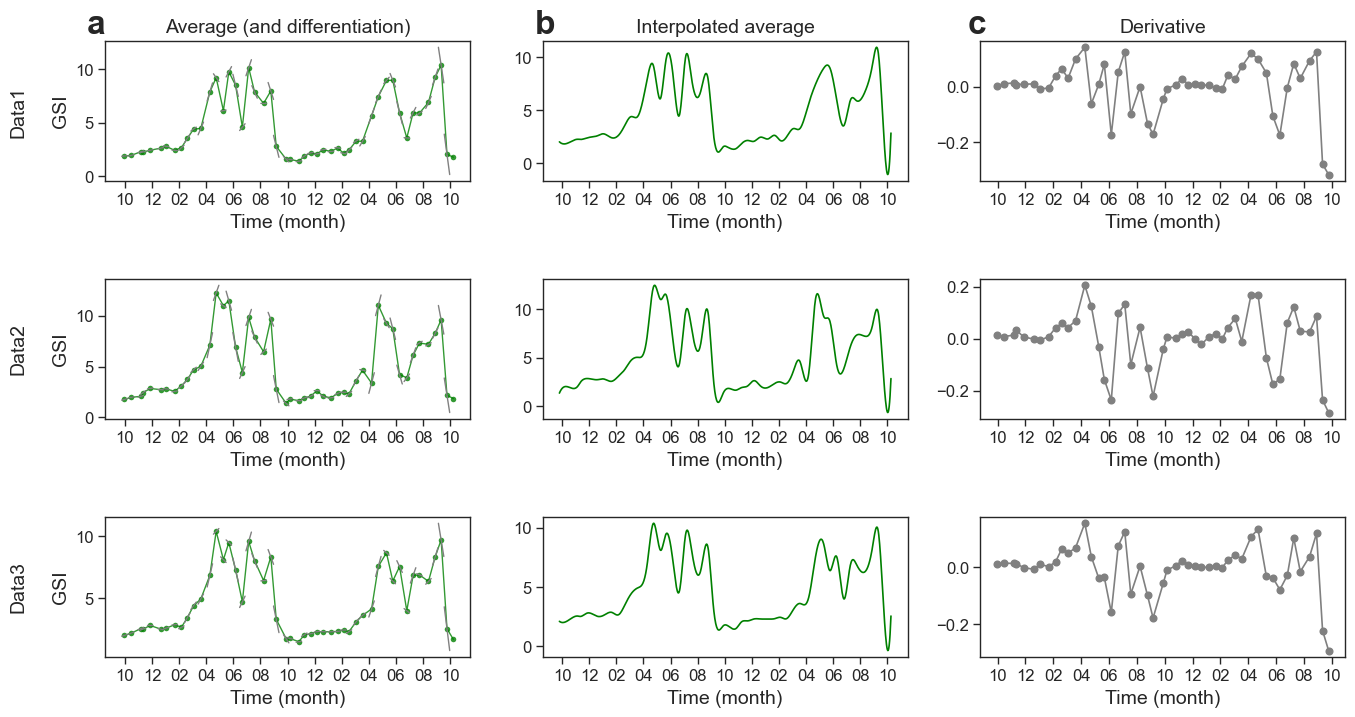

In [119]:
import matplotlib as mpl
import matplotlib
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['pdf.fonttype'] = 42

fig = plt.figure(figsize=(16,8))

AX = [fig.add_subplot(3, 3, i) for i in range(1,10)] # 最初のサブプロット (幅を2倍
fig.subplots_adjust(hspace=0.7)
deltax = 6
AX[0].set_title("Average (and differentiation)", fontsize=14)
AX[1].set_title("Interpolated average", fontsize=14)
AX[2].set_title("Derivative", fontsize=14)

xtemp = np.array([Data1output["Time"]-deltax, Data1output["Time"]+deltax]).T
for i in range(3):
    ytemp = np.array([Data1output[f'Female_mean_for_data{i}']- deltax*Data1output[f'deltaFemaleGSI_for_data{i}'], 
         Data1output[f'Female_mean_for_data{i}']+ deltax*Data1output[f'deltaFemaleGSI_for_data{i}']]).T
    AX[i*3].plot(Data1output["Time"], Data1output[f'Female_mean_for_data{i}'], 'o-', markeredgecolor='none', color='green', markersize=4, linewidth=1, alpha=0.8)
    [AX[i*3].plot(xtemp[j], ytemp[j], '-',c='grey', linewidth=1, markeredgecolor='none') for j in range(xtemp.shape[0]-1)]
    AX[i*3].set_xticks([6+60*i for i in range(13)], ["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"], fontsize=12)
    AX[i*3].tick_params(axis='y', labelsize=12)
    AX[i*3].set_xlabel('Time (month)', fontsize=14)
    AX[i*3].set_ylabel(f'Data{i+1}\n\nGSI', fontsize=14)


for i in range(3):
    AX[i*3+1].plot(Data1input[f'interporated GSI_Female_data{i}'].iloc[0:735,], '-', color='green')
    AX[i*3+1].set_xticks([6+60*i for i in range(13)], ["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"], fontsize=12)
    AX[i*3+1].tick_params(axis='y', labelsize=12)
    AX[i*3+1].set_xlabel('Time (month)', fontsize=14)
    #AX[i*3+1].set_ylabel('GSI', fontsize=14)

for i in range(3):
    AX[i*3+2].plot(Data1output["Time"].iloc[0:48,], Data1output[f'deltaFemaleGSI_for_data{i}'].iloc[0:48,], 'o-', color='grey')
    AX[i*3+2].set_xticks([6+60*i for i in range(13)], ["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"], fontsize=12)
    AX[i*3+2].tick_params(axis='y', labelsize=12)
    AX[i*3+2].set_xlabel('Time (month)', fontsize=14)
    #AX[i*3+2].set_ylabel('GSI', fontsize=14)


fig.text(0.119,0.9, "a", ha='center', va='center', weight='bold', fontsize=24)
fig.text(0.4,0.9, "b", ha='center', va='center', weight='bold', fontsize=24)
fig.text(0.67,0.9, "c", ha='center', va='center', weight='bold', fontsize=24)

#plt.savefig("./SupFig1.pdf")
#fig.tight_layout()

### Visualization of input signals (environmental signals +  GSI)

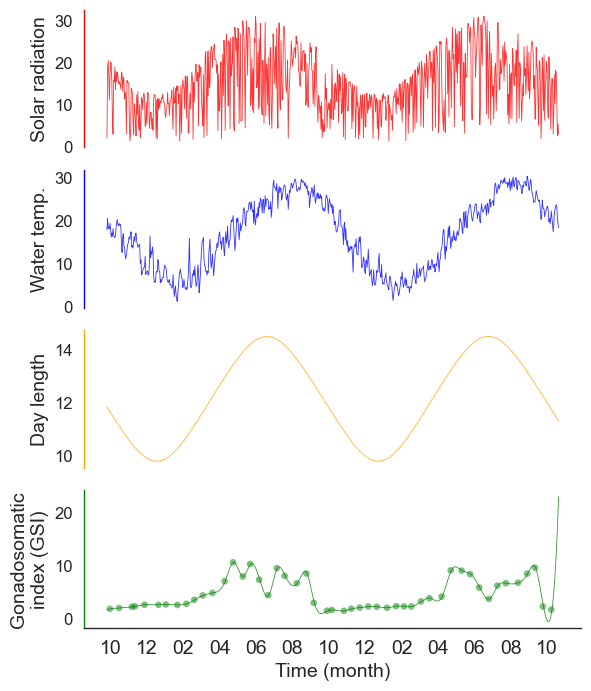

In [120]:
plt.figure(figsize=(6,7)) #,dpi=200
ax = [plt.subplot(4,1,i+1) for i in range(0,4)]
colors = ["red", "blue", "orange", "green"]
ax[0].plot(Data1input["Time"], Data1input["SR"], color=colors[0], alpha=0.8, linewidth=0.6)
ax[1].plot(Data1input["Time"], Data1input["WT"], color=colors[1], alpha=0.8, linewidth=0.6)
ax[2].plot(Data1input["Time"], Data1input["DL"], color=colors[2], alpha=0.8, linewidth=0.6)
ax[3].plot(Data1input["Time"], Data1input["interporated GSI_Female"], color=colors[3], alpha=0.8, linewidth=0.6)
ax[3].scatter(Data1output["Time"], Data1output["Female_mean"], alpha=0.5, color=colors[3], edgecolors='none')

for i in range(0,4):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(left=False, bottom=False)  # Hide the ticks
    ax[i].spines['left'].set_color(colors[i]) 
    ax[i].spines['bottom'].set_visible(False)#set_color(colors[i]) 
    ax[i].tick_params(axis='y', labelsize=12)
    ax[i].set_xticks([]) 
    
    
ax[0].set_ylabel("Solar radiation", fontsize=14)
ax[1].set_ylabel("Water temp.", fontsize=14)
ax[2].set_ylabel("Day length", fontsize=14)
ax[3].set_ylabel("Gonadosomatic\nindex (GSI)", fontsize=14)
ax[3].spines['bottom'].set_visible(True)
ax[i].set_xticks([6+60*i for i in range(13)]) 
ax[i].set_xticklabels(["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"],fontsize=14)
ax[i].set_xlabel("Time (month)", fontsize=14)
plt.tight_layout()

matplotlib.rcParams['pdf.fonttype'] = 42
#plt.savefig("./Fig1parts_env.pdf")


### Standardization of input/output variables

In [121]:
from sklearn.preprocessing import StandardScaler

# Input/output columns to be standardized
input_scale_cols = ["SR", "WT", "DL", 
              "interporated GSI_Female_data0", 
              "interporated GSI_Female_data1", 
              "interporated GSI_Female_data2"]

output_scale_cols = ["deltaFemaleGSI", 
               "deltaFemaleGSI_for_data0", 
               "deltaFemaleGSI_for_data1", 
               "deltaFemaleGSI_for_data2"]

# Fit scalers separately for input (X) and output (y)
scaler_x = StandardScaler().fit(Data1input[input_scale_cols])
scaler_y = StandardScaler().fit(Data1output[output_scale_cols])

# Apply standardization (mean=0, std=1)
Data1input[input_scale_cols] = scaler_x.transform(Data1input[input_scale_cols])
Data1output[output_scale_cols] = scaler_y.transform(Data1output[output_scale_cols])

# Verify scaling results
display(Data1input[input_scale_cols].head())
display(Data1output[output_scale_cols].head())

,SR,WT,DL,interporated GSI_Female_data0,interporated GSI_Female_data1,interporated GSI_Female_data2
0,-1.741775,0.126908,-0.190568,-0.850179,-1.051028,-0.907548
1,0.577547,0.456490,-0.221738,-0.862173,-1.020464,-0.916689
2,0.813481,0.163069,-0.242517,-0.872692,-0.993019,-0.924299
3,0.308500,0.207495,-0.273687,-0.881796,-0.968552,-0.930444
4,-0.498640,0.146022,-0.284076,-0.889546,-0.946920,-0.935194


,deltaFemaleGSI,deltaFemaleGSI_for_data0,deltaFemaleGSI_for_data1,deltaFemaleGSI_for_data2
0,0.136916,0.060673,0.149835,0.171373
1,0.142733,0.139326,0.101259,0.207341
2,0.160617,0.160989,0.155526,0.192358
3,0.230520,0.101412,0.347294,0.191022
4,0.101162,0.117542,0.088011,0.020075


#### Data Properties

We computed variance and covariance of the GSI derivatives (dGSI) across the three data groups.
These statistics are used to estimate observation noise as hyperparameters for the model.

In [122]:
# Data properties. These values are used for the algorithm as a hyperparameter.

# Compute variance and covariance of dGSI across data groups.
# These statistics are used to set observation noise hyperparameters.

dGSIset = ["deltaFemaleGSI_for_data0",
           "deltaFemaleGSI_for_data1",
           "deltaFemaleGSI_for_data2"]

dGSI_var = Data1output.loc[:,dGSIset].var(axis=1)
summary_df = pd.DataFrame(
    {"Variance":  [dGSI_var.mean(), dGSI_var.max()]},
    index=["dGSI-VAR time ave.", "dGSI-VAR max"]
)
display(summary_df)

covariances = {
    "dGSI Data1–Data2": np.cov(Data1output["deltaFemaleGSI_for_data0"], Data1output["deltaFemaleGSI_for_data1"])[0,1],
    "dGSI Data1–Data3": np.cov(Data1output["deltaFemaleGSI_for_data0"], Data1output["deltaFemaleGSI_for_data2"])[0,1],
    "dGSI Data2–Data3": np.cov(Data1output["deltaFemaleGSI_for_data1"], Data1output["deltaFemaleGSI_for_data2"])[0,1],
}
cov_df = pd.DataFrame(covariances, index=["Covariance"]).T
display(cov_df)

,Variance
dGSI-VAR time ave.,0.104359
dGSI-VAR max,1.364782


,Covariance
dGSI Data1–Data2,0.856116
dGSI Data1–Data3,0.941571
dGSI Data2–Data3,0.945215


### Construction of sliding-window input matrix

We construct a sliding-window input matrix from the time-series data.
For each GSI sampling day, we extract a window of `SAMPLE_WIDTH` consecutive days
of environmental variables as input features, paired with the corresponding dGSI as the output.

In [123]:
from typing import Sequence, Tuple
import numpy as np
import pandas as pd
from scipy import interpolate

def create_wide_input_df(
    SAMPLE_WIDTH: int,
    input_df: pd.DataFrame, 
    output_df: pd.DataFrame,
    INPUT_VALUES: list, 
    OUTPUT_VALUES: list) -> Tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:

    """
    Construct a sliding-window input matrix for model training.

    For each GSI sampling day, extract a window of `sample_width` consecutive days
    of input features, paired with the corresponding output (dGSI).
    The last sample is dropped to align inputs with one-step-ahead prediction targets.

    Parameters
    ----------
    sample_width : int
        Number of days in each input window.
    input_df : pd.DataFrame
        Daily environmental input data with a 'Time' column.
    output_df : pd.DataFrame
        GSI output data with a 'Time' column.
    input_cols : list
        Column names to use as input features.
    output_cols : list
        Column names to use as prediction targets.

    Returns
    -------
    wide_input_df : pd.DataFrame
        Wide-format input matrix (samples × flattened window features).
    result_df : pd.DataFrame
        Output DataFrame aligned to valid sampling days.
    result : np.ndarray
        Output values as a numpy array.
    """
    
    #sample widthを確保できるサンプル日を選択
    valid_sample_day = np.array(output_df['Time'])[
        (np.array(output_df['Time']) - SAMPLE_WIDTH) >= 0]
    #GSIサンプル日に目印
    input_df["sample_day"] = False
    input_df.loc[input_df['Time'].isin(np.array(output_df['Time'])), 'sample_day'] = True
    
    #SAMPLE_WIDTHを確保したdf
    pivot_index = 1
    for day in valid_sample_day:
        #tmp_df = input_df.iloc[int(day-SAMPLE_WIDTH):int(day),:].copy() #Exclude sampling day.
        tmp_df = input_df.iloc[int(day-SAMPLE_WIDTH+1):int(day+1),:].copy()  #Include sampling day
        tmp_df.loc[:,"pivot_index"] = pivot_index
        tmp_df.loc[:,"param_index"] = np.arange(0,SAMPLE_WIDTH)
        pivot_index += 1
        if day == valid_sample_day[0]:
            input_sample_df = tmp_df.copy()
        else:
            input_sample_df = pd.concat([input_sample_df, tmp_df], axis=0)

    wide_input_df = input_sample_df.pivot(index=["pivot_index"],columns=["param_index"],
                                          values=INPUT_VALUES)

    result_df = output_df.loc[output_df['Time'].isin(valid_sample_day)]
    
    result = result_df.filter(items=OUTPUT_VALUES, axis=1)
    result.index = np.arange(1, len(result)+1) 

    result = np.delete(result, [-1], 0)
    result_df = result_df.drop(result_df.index[[-1]])
    wide_input_df = wide_input_df.drop(wide_input_df.index[[-1]])
    
    if wide_input_df.shape[1] != SAMPLE_WIDTH*len(INPUT_VALUES):
        raise ValueError("DF creation failed")

    return(wide_input_df,result_df, np.array(result))



# --- Demonstration ---
window_size = 3
OUTPUT_VALUES = ["deltaFemaleGSI_for_data0", 
                 "deltaFemaleGSI_for_data1", 
                 "deltaFemaleGSI_for_data2"]
INPUT_VALUES = ["SR","WT","DL", 
                "interporated GSI_Female_data0", 
                "interporated GSI_Female_data1", 
                "interporated GSI_Female_data2"]

wide_input_df, result_df, result = create_wide_input_df(
    window_size, Data1input, Data1output, INPUT_VALUES, OUTPUT_VALUES)  


print("Input features (original):")
display(Data1input.head(6))
print("\nInput features (sliding-window wide format):")
display(wide_input_df.head())
print("\nOutput (dGSI):")
display(result_df[OUTPUT_VALUES].head())

Input features (original):


,Time,Time_raw,SR,WT,SL,DL,interporated GSI_Female,interporated GSI_Male,interporated GSI_Female_data0,interporated GSI_Female_data1,interporated GSI_Female_data2,sample_day
0,0.0,2015-10-01,-1.741775,0.126908,0.0,-0.190568,1.796218,0.585118,-0.850179,-1.051028,-0.907548,False
1,1.0,2015-10-02,0.577547,0.456490,8.1,-0.221738,1.816638,0.582826,-0.862173,-1.020464,-0.916689,False
2,2.0,2015-10-03,0.813481,0.163069,10.8,-0.242517,1.835876,0.581847,-0.872692,-0.993019,-0.924299,False
3,3.0,2015-10-04,0.308500,0.207495,9.2,-0.273687,1.853989,0.582103,-0.881796,-0.968552,-0.930444,False
4,4.0,2015-10-05,-0.498640,0.146022,1.0,-0.284076,1.871031,0.583515,-0.889546,-0.946920,-0.935194,False
5,5.0,2015-10-06,0.257451,0.307197,7.0,-0.304856,1.887060,0.586004,-0.896002,-0.927981,-0.938617,True



Input features (sliding-window wide format):


SR                            WT                      \
param_index         0         1         2         0         1         2   
pivot_index                                                               
1            0.308500 -0.498640  0.257451  0.207495  0.146022  0.307197   
2            0.340234  0.032555  0.028416  0.271552  0.240557  0.309263   
3           -1.570689 -0.112317 -0.175784  0.047354  0.064917 -0.376764   
4           -1.645194 -0.618677 -0.838053 -0.190276 -0.070428 -0.222821   
5           -0.351009 -0.264087 -0.406199 -0.981170 -0.984270 -0.938810   

                   DL                     interporated GSI_Female_data0  \
param_index         0         1         2                             0   
pivot_index                                                               
1           -0.273687 -0.284076 -0.304856                     -0.881796   
2           -0.595771 -0.626940 -0.647720                     -0.889551   
3           -1.021753 -1.042533 -1.063312                     -0.775317   
4           -1.115261 -1.125651 -1.146431                     -0.778181   
5           -1.343837 -1.354227 -1.364617                     -0.737684   

                                interporated GSI_Female_data1            \
param_index         1         2                             0         1   
pivot_index                                                               
1           -0.889546 -0.896002                     -0.968552 -0.946920   
2           -0.884210 -0.878478                     -0.862172 -0.866012   
3           -0.774404 -0.774364                     -0.871553 -0.857323   
4           -0.779625 -0.780549                     -0.779479 -0.758202   
5           -0.733712 -0.730039                     -0.618523 -0.618015   

                      interporated GSI_Female_data2                      
param_index         2                             0         1         2  
pivot_index                                                              
1           -0.927981                     -0.930444 -0.935194 -0.938617  
2           -0.870412                     -0.893513 -0.885548 -0.877283  
3           -0.840668                     -0.754372 -0.754492 -0.755751  
4           -0.738004                     -0.763931 -0.766163 -0.767109  
5           -0.618070                     -0.677845 -0.672442 -0.668294


Output (dGSI):


,deltaFemaleGSI_for_data0,deltaFemaleGSI_for_data1,deltaFemaleGSI_for_data2
0,0.060673,0.149835,0.171373
1,0.139326,0.101259,0.207341
2,0.160989,0.155526,0.192358
3,0.101412,0.347294,0.191022
4,0.117542,0.088011,0.020075


## Inverse Signal Importance (ISI)  (Single-Group Demonstration)

In [124]:
# -------------------------------------------------------------------
# Build sliding-window dataset for model training
# -------------------------------------------------------------------

input_cols=['SR','WT','DL',
            'interporated GSI_Female_data0',
            'interporated GSI_Female_data1',
           'interporated GSI_Female_data2']
output_cols=['deltaFemaleGSI_for_data0',
             'deltaFemaleGSI_for_data1',
             'deltaFemaleGSI_for_data2']

window_size=3
X_wide, result_df, Y = create_wide_input_df(
            window_size, Data1input, Data1output, input_cols, output_cols
        )

train_common = ["SR", "WT", "DL"]
gsi_columns = [f"interporated GSI_Female_data{i}" for i in range(3)]
train_sets = [train_common + [gsi] for gsi in gsi_columns]
X_multi = np.array([np.array(X_wide[cols]) for cols in train_sets])  # shape: (3, N, 4)
X1, X2, X3 = X_multi[0], X_multi[1], X_multi[2]
Y1, Y2, Y3 = Y[:,0], Y[:,1], Y[:,2]
real_times = result_df["Time"].to_numpy()

In [125]:
# -------------------------------------------------------------------
# Model training and testing
# -------------------------------------------------------------------

import ISI

em = ISI.EMAlgorithm(
    window_size=window_size,
    process_noise_var=8.0
)

signalimp, P_smooth, responsefunc, rss, rss_history = em.fit(
    X_list = [X1, X2],
    Y_list = [Y1, Y2],
    times = real_times,
    n_signals=4
)

test_score, _ = em.test(
    X_list = [X3],
    Y_list = [Y3],
    x_smooth = signalimp,
    coef = responsefunc
)

data = {"Time": real_times, "SR": signalimp[:,0],  "WT": signalimp[:,1], "DL": signalimp[:,2], "GSI": signalimp[:,3]}
timevariable_df = pd.DataFrame(data=data)
    
print("Test RSS:", test_score)
print("Smoothed states (Signal importance) shape:", signalimp.shape)
print("Covariance matrices shape:", P_smooth.shape)

print("\nSignal importance:")
display(timevariable_df.head(4))

rss: 0.8846340913836905
Test RSS: 1.0908564156591598
Smoothed states (Signal importance) shape: (48, 4)
Covariance matrices shape: (48, 4, 4)

Signal importance:


,Time,SR,WT,DL,GSI
0,5,1.413971,0.548131,-2.468048,6.569787
1,20,1.394932,0.341088,-2.492413,6.814799
2,41,1.410556,0.054764,-2.516890,7.020957
3,46,1.311869,-0.021609,-2.630279,7.247498


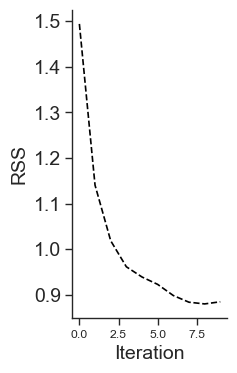

In [126]:
# -------------------------------------------------------------------
# Confirm convergence of the EM Algorithm
# RSS as a function of EM iteration steps.
# -------------------------------------------------------------------

import matplotlib as mpl
import matplotlib
mpl.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(2,4))
plt.plot(rss_history, color="black",linestyle='dashed')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel("RSS", fontsize=14)
plt.tick_params(axis='y', labelsize=14)
matplotlib.rcParams['pdf.fonttype'] = 42
#plt.savefig("./Fig2parts_RSS.pdf")

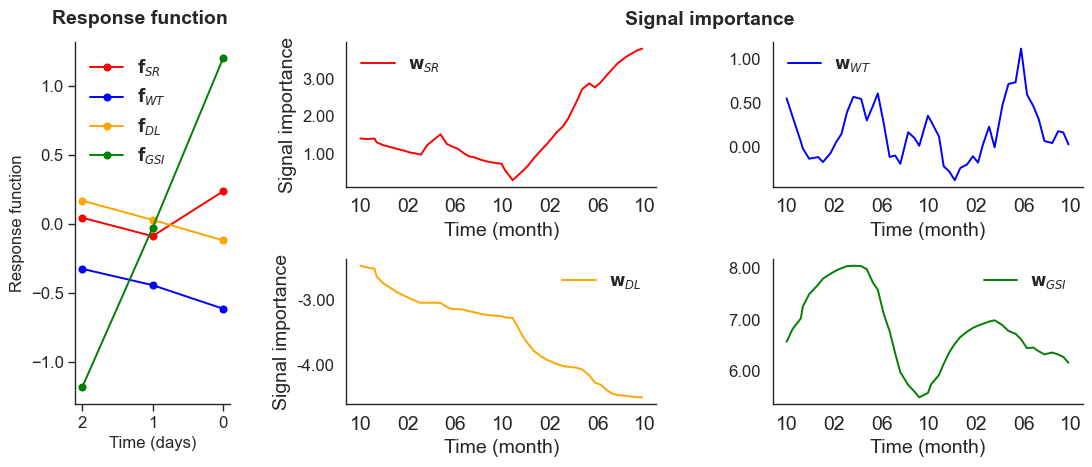

In [127]:
# -------------------------------------------------------------------
# Visualization of ISI: estimated Response function x Signal importance
# Layout: A (response function) | B (signal importance, 2x2 panels)
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import FormatStrFormatter
import numpy as np

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["pdf.fonttype"] = 42

fig = plt.figure(figsize=(13, 4.7))
gs  = fig.add_gridspec(2, 3, width_ratios=[1, 2, 2], wspace=0.45, hspace=0.5)

ax_a    = fig.add_subplot(gs[:, 0])          # A: full-height left panel
ax_b    = [fig.add_subplot(gs[r, c+1])       # B: 2x2 right panels
           for r in range(2) for c in range(2)]

labels_w = [r"$\mathbf{w}_{SR}$",  r"$\mathbf{w}_{WT}$",
            r"$\mathbf{w}_{DL}$",  r"$\mathbf{w}_{GSI}$"]
labels_f = [r"$\mathbf{f}_{SR}$",  r"$\mathbf{f}_{WT}$",
            r"$\mathbf{f}_{DL}$",  r"$\mathbf{f}_{GSI}$"]
colors   = ["red", "blue", "orange", "green"]

# -------------------------------------------------------------------
# Panel A: response functions
# -------------------------------------------------------------------
S = window_size
linear_filters = np.array([responsefunc[i*S:(i+1)*S] for i in range(4)])

for seg, col, lab in zip(linear_filters, colors, labels_f):
    ax_a.plot(seg, "o-", color=col, linewidth=1.4, alpha=1, label=lab)

ax_a.set_ylabel("Response function", fontsize=12)
ax_a.set_xlabel("Time (days)", fontsize=12)
ax_a.set_xticks(range(S))
ax_a.set_xticklabels(range(S-1, -1, -1), fontsize=12)
ax_a.tick_params(axis="y", labelsize=12)
ax_a.legend(loc="best", fontsize=12, frameon=False)
ax_a.spines[["top", "right"]].set_visible(False)
ax_a.text(-0.15, 1.05, "Response function", transform=ax_a.transAxes,
          fontsize=14, fontweight="bold")
# -------------------------------------------------------------------
# Panel B: time-varying signal importance (2x2)
# -------------------------------------------------------------------
signals = ["SR", "WT", "DL", "GSI"]

for i, (sig, col, lab) in enumerate(zip(signals, colors, labels_w)):
    ax_b[i].plot(timevariable_df["Time"], timevariable_df[sig],
                 color=col, alpha=1, linewidth=1.4, label=lab)
    ax_b[i].legend(fontsize=12, frameon=False)
    ax_b[i].spines[["top", "right"]].set_visible(False)
    ax_b[i].spines["bottom"].set_visible(True)
    ax_b[i].tick_params(left=False, bottom=False)
    ax_b[i].tick_params(axis="y", labelsize=12)
    ax_b[i].set_xticks([6 + 120*j for j in range(7)])
    ax_b[i].set_xticklabels(["10","02","06","10","02","06","10"], fontsize=14)
    ax_b[i].set_xlabel("Time (month)", fontsize=14)
    ax_b[i].yaxis.set_major_formatter(FormatStrFormatter("%1.2f"))

ax_b[0].set_ylabel("Signal importance", fontsize=14)
ax_b[2].set_ylabel("Signal importance", fontsize=14)
ax_b[1].set_ylabel("")
ax_b[3].set_ylabel("")

ax_b[0].text(0.9, 1.12, "Signal importance", transform=ax_b[0].transAxes,
             fontsize=14, fontweight="bold")



# fig.savefig("./FiguresV2/Fig2_combined.pdf", bbox_inches="tight")
plt.show()

### Visualizatoin of prediction result

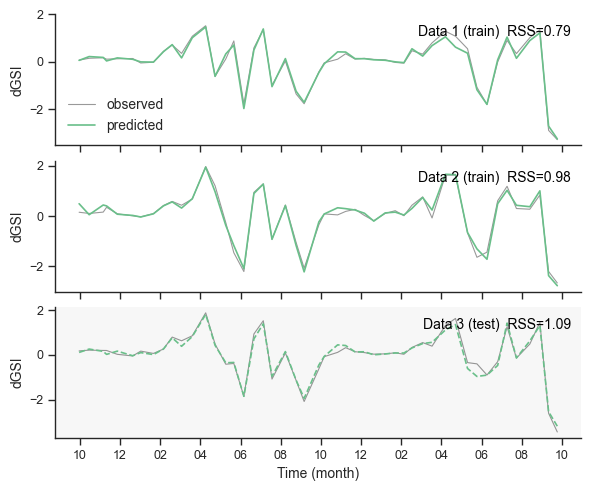

In [128]:
# -------------------------------------------------------------------
# Observed vs. predicted dGSI: train groups (X1, X2) + test group (X3)
# -------------------------------------------------------------------

# Build transA from responsefunc (same logic as ISI.test() internal)
n_signals = signalimp.shape[1]
transA = np.zeros((n_signals * window_size, n_signals))
for i in range(1, n_signals + 1):
    start = window_size * (i - 1)
    end   = window_size * i
    transA[start:end, i-1] = responsefunc[start:end]

X_groups   = [X1, X2, X3]
Y_groups   = [Y1, Y2, Y3]
group_labels = ["Data 1 (train)", "Data 2 (train)", "Data 3 (test)"]
linestyles   = ["-", "-", "--"]

fig, ax = plt.subplots(3, 1, figsize=(6, 5), sharex=True)

for i in range(3):
    H     = X_groups[i] @ transA
    T_len = H.shape[0]
    predy = np.array([H[t] @ signalimp[t] for t in range(T_len)])
    testy = Y_groups[i]
    RSS   = np.sum((predy - testy) ** 2)

    ax[i].plot(real_times, testy,
               color="black", alpha=0.4, linewidth=0.8, label="observed")
    ax[i].plot(real_times, predy,
               color="#6abf8a", linestyle=linestyles[i], linewidth=1.2, label="predicted")

    ax[i].set_yticks([-2, 0, 2])
    ax[i].set_ylabel("dGSI", fontsize=10)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].tick_params(axis="both", labelsize=9)

    # テスト群は背景色で区別
    if i == 2:
        ax[i].set_facecolor("#f7f7f7")

    ax[i].text(0.98, 0.92, f"{group_labels[i]}  RSS={RSS:.2f}",
               transform=ax[i].transAxes,
               ha="right", va="top", fontsize=10, color="black")

ax[-1].set_xticks([6 + 60*j for j in range(13)])
ax[-1].set_xticklabels(
    ["10","12","02","04","06","08","10","12","02","04","06","08","10"],
    fontsize=9,
)
ax[-1].set_xlabel("Time (month)", fontsize=10)

ax[0].legend(fontsize=10, frameon=False, loc="lower left")

plt.tight_layout(h_pad=0.5)
matplotlib.rcParams["pdf.fonttype"] = 42
# fig.savefig("./SupFig2parts_testtrain_demo.pdf", bbox_inches="tight")
plt.show()

## Hyperparameter Selection via Grid Search with 3-Fold Cross-Validation

We perform a grid search over `window_size` and `process_noise_var`,
evaluated by 3-fold cross-validation across the three data groups.
The hyperparameter combination yielding the lowest mean test RSS is selected.

In [129]:
# ---------------------------------------------------------------
# 0. Hyperparameter search space
# ---------------------------------------------------------------
WINDOW_SIZES   = range(2, 10)       
PROCESS_NOISES = range(1, 20)          
DATA_SPLITS    = [[0, 1, 2], [2, 0, 1], [1, 2, 0]] # 3-fold Cross-Validation

COMMON_COLS = ["SR", "WT", "DL"]
GSI_INPUT_COLS  = [f"interporated GSI_Female_data{i}" for i in range(3)]
GSI_OUTPUT_COLS = [f"deltaFemaleGSI_for_data{i}"      for i in range(3)]

# Result matrices: rows = window_size, cols = process_noise
cv_scores = np.zeros((len(WINDOW_SIZES), len(PROCESS_NOISES)))
cv_stds = np.zeros((len(WINDOW_SIZES), len(PROCESS_NOISES)))

# ---------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------
def build_input_matrices(window_size: int):
    X_wide, result_df, Y = create_wide_input_df(
        window_size,
        Data1input,
        Data1output,
        COMMON_COLS + GSI_INPUT_COLS,
        GSI_OUTPUT_COLS,
    )
    # shape: (n_groups=3, n_samples, n_features=4)
    X_multi = np.stack([
        X_wide[COMMON_COLS + [g]].to_numpy() for g in GSI_INPUT_COLS
    ])
    return X_multi, result_df["Time"].to_numpy(), Y


def split_train_test(X_multi: np.ndarray, Y: np.ndarray, split: list):
    a, b, c = split
    train_X = [X_multi[a], X_multi[b]]
    train_Y = [Y[:, a],    Y[:, b]]
    test_X  = [X_multi[c]]
    test_Y  = [Y[:, c]]
    return train_X, train_Y, test_X, test_Y

# ----------------------------------------------------------------------------------
# 2. Grid search: window_size × process_noise_var. 3-fold CV in each parameter set
# ----------------------------------------------------------------------------------
alpha_ = 1.0
for w_idx, w_size in enumerate(WINDOW_SIZES):

    # window_size ごとにデータを一度だけ生成
    X_multi, time_axis, Y = build_input_matrices(w_size)

    for p_idx, p_noise in enumerate(PROCESS_NOISES):

        split_scores = []               # store 3-fold data

        for split in DATA_SPLITS:       
            trX, trY, teX, teY = split_train_test(X_multi, Y, split)

            em = ISI.EMAlgorithm(window_size=w_size,
                                 process_noise_var=p_noise,
                                alpha=alpha_
                                ) #0.1はいいかんじだった.

            x_sm, P_sm, coef, *_ = em.fit(
                X_list=trX,
                Y_list=trY,
                times=time_axis,
                n_signals=4,
            )

            test_score, _ = em.test(
                X_list=teX,
                Y_list=teY,
                x_smooth=x_sm,
                coef=coef,
            )
            split_scores.append(test_score)

        cv_scores[w_idx, p_idx] = np.mean(split_scores)
        cv_stds[w_idx, p_idx] = np.std(split_scores)

        print(f"window:{w_size}, noise={p_noise}, score={cv_scores[w_idx, p_idx]}, std={cv_stds[w_idx, p_idx]}")

# ---------------------------------------------------------------
# 3. Result
# ---------------------------------------------------------------
best_idx       = np.unravel_index(cv_scores.argmin(), cv_scores.shape)
best_window    = WINDOW_SIZES[best_idx[0]]
best_p_noise   = PROCESS_NOISES[best_idx[1]]
best_cv_score  = cv_scores[best_idx]

print(f"Best → window={best_window}, noise={best_p_noise}, score={best_cv_score:.4f}")


rss: 2.1599356195031043
rss: 1.0532458970337322
rss: 2.458088552668789
window:2, noise=1, score=2.358873151385195, std=0.3222278926588928
rss: 1.3035912118641393
rss: 0.8845740479151607
rss: 1.4665386697605558
window:2, noise=2, score=1.7616234895854397, std=0.5157219223392051
rss: 1.0769678143589796
rss: 1.1299782722681317
rss: 1.1451532715211983
window:2, noise=3, score=1.7115544426711704, std=0.6836054525144756
rss: 0.9626036715287323
rss: 0.6502251898204013
rss: 0.9983962376090112
window:2, noise=4, score=1.5714396282839225, std=0.5821261627639873
rss: 0.8972277068039894
rss: 0.5388971495490431
rss: 0.9080403173252691
window:2, noise=5, score=1.492529057469068, std=0.5150996220955854
rss: 0.8533979401729178
rss: 0.5033835120460456
rss: 0.8491073952809357
window:2, noise=6, score=1.4703519638441798, std=0.5187126165928702
rss: 0.8212976412733082
rss: 0.5545833902675741
rss: 0.8036206239568964
window:2, noise=7, score=1.4536822597879595, std=0.5166708547214033
rss: 0.7953211022885309

Best → window=2, noise=19, score=1.3850


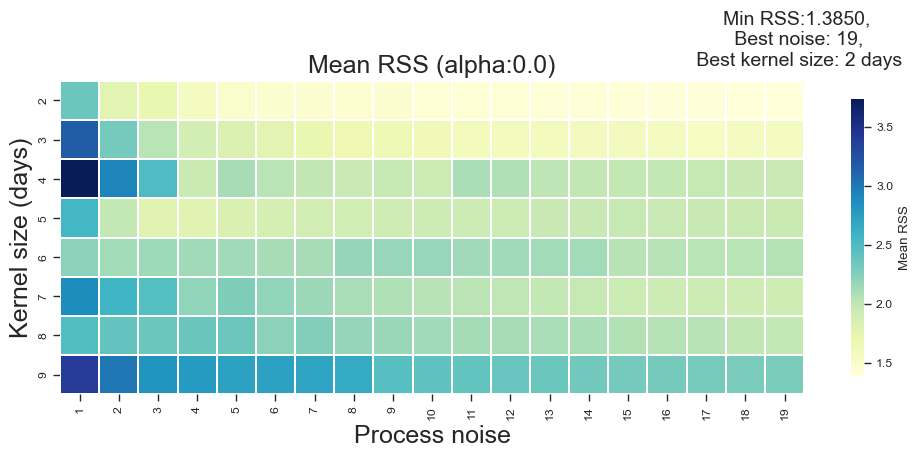

<Figure size 640x480 with 0 Axes>

In [130]:
print(f"Best → window={best_window}, noise={best_p_noise}, score={best_cv_score:.4f}")
fig, ax = plt.subplots(figsize=(12,12),facecolor="white")
sns_heatmap = sns.heatmap(cv_scores,cmap="YlGnBu", square=True, linewidths=.25, 
                          cbar_kws={"shrink": 0.3, "label": "Mean RSS"})

ax.set_xlabel("Process noise",fontsize=18)
ax.set_ylabel("Kernel size (days)",fontsize=18)
ax.set_xticklabels(PROCESS_NOISES,rotation=90)
ax.set_yticklabels(WINDOW_SIZES,rotation=90)
plt.title(f"Mean RSS (alpha:{0.0})",fontsize=18)
plt.text(0.99,1.05, 'Min RSS:{:.4f},\n Best noise: {},\n Best kernel size: {} days'.
         format(best_cv_score ,best_p_noise, best_window),fontsize=14,
         ha='center', transform=ax.transAxes)

plt.show(sns_heatmap)
plt.subplots_adjust(bottom=2, top=10)

matplotlib.rcParams['pdf.fonttype'] = 42
#fig.savefig("./FiguresV2/supfig.pdf")#

### Equivalent Hyperparameter Combinations

In [131]:
# ---------------------------------------------------------------
# Select top hyperparameter combinations from grid search results
# ---------------------------------------------------------------

def round_half_up(x: float) -> float:
    """Round up to the nearest 0.5 increment (e.g., 0.26 → 0.5, 0.74 → 0.5, 1.5 → 1.5, 1.9 → 2.0)."""
    return np.round(x * 2) / 2
    
# Threshold: best CV score rounded up to the nearest 0.5
round_min_score = round_half_up(np.min(cv_scores))

# Rank all hyperparameter combinations by CV score (ascending)
flat_sorted_idx = np.argsort(cv_scores.ravel())


# Collect top k combinations within the score threshold
k = 50
top_parameters = []

for rank, idx in enumerate(flat_sorted_idx[:k], start=1):
    i, j = np.unravel_index(idx, cv_scores.shape)
    round_score =  round_half_up(cv_scores[i, j])
    display(f"No.{rank}: "
            f"window_size={WINDOW_SIZES[i]}, "
            f"process_noise={PROCESS_NOISES[j]}, "
            f"score={cv_scores[i, j]:.2f}")
    if round_score <= round_min_score:         
        top_parameters.append([WINDOW_SIZES[i], PROCESS_NOISES[j]])
    else:
        break

top_parameters = np.array(top_parameters)
# Extract window size > 2 for capture the entire structure of resposne function.
stable_top_parameters = top_parameters[(top_parameters[:,0] > 2),]

'No.1: window_size=2, process_noise=19, score=1.39'

'No.2: window_size=2, process_noise=18, score=1.39'

'No.3: window_size=2, process_noise=17, score=1.40'

'No.4: window_size=2, process_noise=16, score=1.40'

'No.5: window_size=2, process_noise=15, score=1.41'

...

'No.27: window_size=3, process_noise=9, score=1.64'

'No.28: window_size=3, process_noise=8, score=1.67'

'No.29: window_size=3, process_noise=7, score=1.71'

'No.30: window_size=2, process_noise=3, score=1.71'

'No.31: window_size=3, process_noise=6, score=1.75'

### Ensemble Model over Equivalent Hyperparameter Combinations

> We fit the full model (all three data groups) for each hyperparameter combination
> selected in the previous step, and aggregate the results.
> Parameter combinations are retained based on CV score, process noise strength,
> and window size stability.

In [132]:
import ISI
import importlib
importlib.reload(ISI)

timevariable_df_list = list()
coef_list = list()
rss_list = list()
for window_size, process_noise in stable_top_parameters:
    print(f"window:{window_size}, noise={process_noise} ")
    X_wide, result_df, Y = create_wide_input_df(
                window_size, Data1input, Data1output, input_cols, output_cols
            )
    
    real_times = result_df["Time"].to_numpy()
    train_common = ["SR", "WT", "DL"]
    gsi_columns = [f"interporated GSI_Female_data{i}" for i in range(3)]
    train_sets = [train_common + [gsi] for gsi in gsi_columns]
    X_multi = np.array([np.array(X_wide[cols]) for cols in train_sets])  # shape: (3, N, 4)
    X1, X2, X3 = X_multi[0], X_multi[1], X_multi[2]
    Y1, Y2, Y3 = Y[:,0], Y[:,1], Y[:,2]


    em = ISI.EMAlgorithm(
        window_size=window_size,
        process_noise_var=process_noise,
        alpha = alpha_
    )
    
    # Full model.
    x_smooth, P_smooth, linearcoef, rss, rss_history = em.fit(
        X_list = [X1, X2, X3],
        Y_list = [Y1, Y2, Y3],
        times = real_times,
        n_signals = 4
    )
    rss_list.append(rss)
    
    data = {"Time": real_times, "SR": x_smooth[:,0],  "WT": x_smooth[:,1], "DL": x_smooth[:,2], "GSI": x_smooth[:,3]}
    timevariable_df = pd.DataFrame(data=data)
    timevariable_df_list.append(timevariable_df)
    coef_list.append(linearcoef)
print(f"rss mean: {np.mean(rss_list)}")

window:3, noise=17 
rss: 0.6170324843544348
(48, 4)
window:3, noise=16 
rss: 0.6252234517259196
(48, 4)
window:3, noise=19 
rss: 0.6044465383357218
(48, 4)
window:3, noise=18 
rss: 0.6108448139691417
(48, 4)
window:3, noise=15 
rss: 0.6348826726554657
(48, 4)
window:3, noise=14 
rss: 0.6442529296812163
(48, 4)
window:3, noise=13 
rss: 0.6570381878534021
(48, 4)
window:3, noise=12 
rss: 0.6702127349646744
(48, 4)
window:3, noise=11 
rss: 0.6876283174870673
(48, 4)
window:3, noise=10 
rss: 0.7069505222655446
(48, 4)
window:3, noise=9 
rss: 0.7315391549476756
(48, 4)
window:3, noise=8 
rss: 0.7578925009434029
(48, 4)
window:3, noise=7 
rss: 0.7939805213279835
(48, 4)
rss mean: 0.6724557561932039


In [133]:
top_rank_tv = [np.array(timevariable_df[["SR", "WT", "DL", "GSI"]]) for timevariable_df in timevariable_df_list]
top_rank_tv_mean = np.mean(top_rank_tv, axis=0)
data = {"Time": timevariable_df_list[0]["Time"], "Time_raw": result_df["Time_raw"], "SR": top_rank_tv_mean[:,0],  "WT": top_rank_tv_mean[:,1], "DL": top_rank_tv_mean[:,2], "GSI": top_rank_tv_mean[:,3]}
timevariable_mean_df = pd.DataFrame(data=data)
display(timevariable_mean_df.head())

,Time,Time_raw,SR,WT,DL,GSI
0,5,2015-10-06 19:00:00,0.447514,0.467484,0.754039,5.204540
1,20,2015-10-21 19:00:00,0.375109,0.291934,0.734585,5.435191
2,41,2015-11-11 19:00:00,0.360376,0.159782,0.727482,5.642617
3,46,2015-11-16 19:00:00,0.283125,0.095744,0.676192,5.929421
4,62,2015-12-02 19:00:00,0.293463,-0.051017,0.633934,6.293711


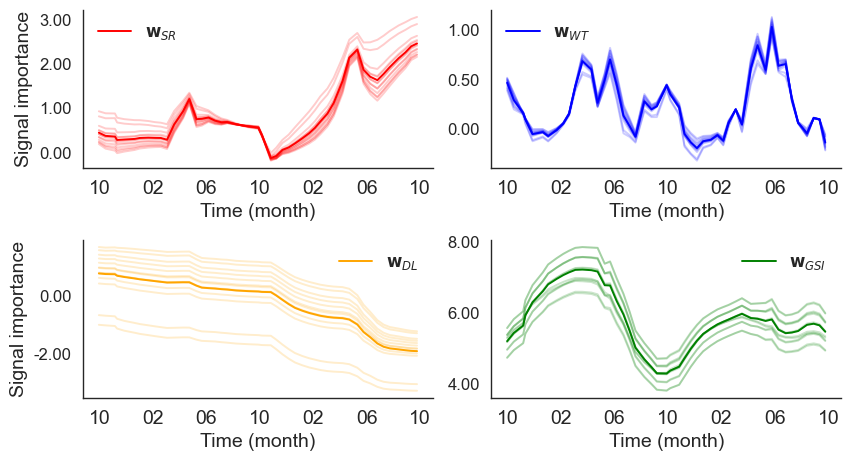

In [134]:
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
#8.6 x 4.7
plt.figure(figsize=(8.6, 4.7)) #unit: pixe;
ax = [plt.subplot(2,2,i+1) for i in range(0,4)]

#plt.figure(figsize=(6,6)) #,dpi=200
#ax = [plt.subplot(2,2,i+1) for i in range(0,4)]
labels = [
    r"$\mathbf{w}_{SR}$",
    r"$\mathbf{w}_{WT}$",
    r"$\mathbf{w}_{DL}$",
    r"$\mathbf{w}_{GSI}$"
]
for timevariable_df in timevariable_df_list:
    colors = ["red", "blue", "orange", "green"]
    ax[0].plot(timevariable_df["Time"], timevariable_df["SR"], color=colors[0], alpha=0.2, linewidth=1.4)
    ax[1].plot(timevariable_df["Time"], timevariable_df["WT"], color=colors[1], alpha=0.2, linewidth=1.4)
    ax[2].plot(timevariable_df["Time"], timevariable_df["DL"], color=colors[2], alpha=0.2, linewidth=1.4)
    ax[3].plot(timevariable_df["Time"], timevariable_df["GSI"], color=colors[3], alpha=0.2, linewidth=1.4)
    

    
for i in range(0,4):
    ax[i].plot(timevariable_df["Time"], top_rank_tv_mean[:,i], color=colors[i], alpha=1, linewidth=1.4, label=labels[i])
    ax[i].legend(fontsize=12, frameon=False)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(left=False, bottom=False)  # Hide the ticks
    ax[i].tick_params(axis='y', labelsize=12)


    ax[i].spines['bottom'].set_visible(True)
    #ax[i].set_xticks([6+60*j for j in range(13)]) 
    #ax[i].set_xticklabels(["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"],fontsize=14)
    
    ax[i].set_xticks([6+120*j for j in range(7)]) 
    ax[i].set_xticklabels(["10", "02", "06", "10", "02","06","10"],fontsize=14)
    ax[i].set_xlabel("Time (month)", fontsize=14)
    #ax[i].set_xticks([]) 
    ax[i].yaxis.set_major_formatter(FormatStrFormatter('%1.2f'))
        
        
    ax[0].set_ylabel("Signal importance", fontsize=14)
    ax[1].set_ylabel("", fontsize=14)
    ax[2].set_ylabel("Signal importance", fontsize=14)
    ax[3].set_ylabel("", fontsize=14)
    
    
    
    #ax[0].set_ylim([-0.2,2.5])
    #ax[1].set_ylim([-0.2,2.5])
    #ax[2].set_ylim([-16.0,-18])
    #ax[2].yaxis.set_major_formatter(FormatStrFormatter('%1.1f'))
    #ax[3].set_ylim([4.0,6.5])
    
    plt.tight_layout()
    
    matplotlib.rcParams['pdf.fonttype'] = 42
    #plt.savefig("./FiguresV2/Fig2e_raw.pdf")
    #plt.savefig("./LSRPosterFig.pdf")


[[ 0.09302382 -0.19272007  0.33573771]
 [-0.2686314  -0.37809597 -0.64962503]
 [ 0.03903881  0.02260648  0.01312593]
 [-1.43081256 -0.02966906  1.41453514]]


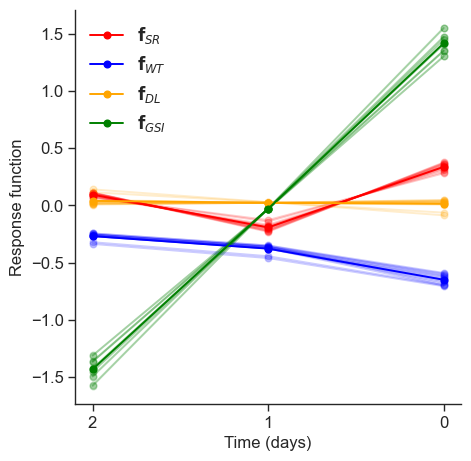

In [135]:
import matplotlib.pyplot as plt
import numpy as np

S = int(np.max([len(coef) for coef in coef_list])/4)
linear_filters = np.array([[coef[i*S:(i+1)*S] for i in range(4)] for coef in coef_list])
linear_filter_mean = np.mean(linear_filters,axis=0)
print(linear_filter_mean)

# ---- 基本設定 ------------------------------------------------
plt.figure(figsize=(4.8, 4.7), facecolor="white")


labels = [
    r"$\mathbf{f}_{SR}$",
    r"$\mathbf{f}_{WT}$",
    r"$\mathbf{f}_{DL}$",
    r"$\mathbf{f}_{GSI}$"
]
colors = ["red", "blue", "orange", "green"]
for linear_filter in linear_filters:
    
    for seg, col, lab in zip(linear_filter, colors, labels):
        plt.plot(seg, "o-", color=col, linewidth=1.4, alpha=0.2)

for seg, col, lab in zip(linear_filter_mean, colors, labels):
    plt.plot(seg, "o-", color=col, label=lab, linewidth=1.4, alpha=1)


plt.ylabel("Response function", fontsize=12)
plt.xlabel("Time (days)", fontsize=12)
plt.xticks(range(S), range(S-1, -1, -1), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc="best",fontsize=12, frameon=False)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
matplotlib.rcParams['pdf.fonttype'] = 42
#plt.savefig("./FiguresV2/Fig2d_raw.pdf")

## Data Export and Subsequent Analysis

Using the estimated signal importance, we proceed to compare it with
the internal state of medaka (gene expression profiles).
The downstream analysis consists of the following two steps:

1. **Randomization of signal importance** for statistical testing of the comparison
   → [`iaaft/RandomizeSignalImportance.ipynb`](/iaaft/RandomizeSignalImportance.ipynb)
2. **Comparison with gene expression profiles**
   → [`rnaseq_analysis/Medaka_RNAseq_analysis.Rmd`](/rnaseq_analysis/Medaka_RNAseq_analysis.Rmd)

In [136]:
import os

# Export averaged signal importance for downstream analysis in R.
# Skipped if the file already exists to prevent accidental overwriting.

output_dir  = "./results"
output_path = os.path.join(output_dir, "SignalImportance_average.csv")
os.makedirs(output_dir, exist_ok=True)
if not os.path.exists(output_path):
    timevariable_mean_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
else:
    print(f"Already exists, skipped: {output_path}")

Already exists, skipped: ./TV0603_alpha0win3noisemean/SignalImportance_average.csv


In [1]:
import subprocess
subprocess.Popen(["jupyter", "notebook", "iaaft/RandomizeSignalImportance.ipynb"])

<Popen: returncode: None args: ['jupyter', 'notebook', 'iaaft/RandomizeSigna...>

[I 2026-03-31 15:33:08.489 ServerApp] jupyter_lsp | extension was successfully linked.
[I 2026-03-31 15:33:08.492 ServerApp] jupyter_server_terminals | extension was successfully linked.
[I 2026-03-31 15:33:08.495 ServerApp] jupyterlab | extension was successfully linked.
[I 2026-03-31 15:33:08.497 ServerApp] notebook | extension was successfully linked.
[I 2026-03-31 15:33:08.708 ServerApp] notebook_shim | extension was successfully linked.
[I 2026-03-31 15:33:08.770 ServerApp] notebook_shim | extension was successfully loaded.
[I 2026-03-31 15:33:08.771 ServerApp] jupyter_lsp | extension was successfully loaded.
[I 2026-03-31 15:33:08.772 ServerApp] jupyter_server_terminals | extension was successfully loaded.
[I 2026-03-31 15:33:08.775 LabApp] JupyterLab extension loaded from /Users/itoutouma/local_python/lib/python3.12/site-packages/jupyterlab
[I 2026-03-31 15:33:08.775 LabApp] JupyterLab application directory is /Users/itoutouma/local_python/share/jupyter/lab
[I 2026-03-31 15:33:0